In [2]:
%pip install scapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 5.8 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [116]:
from scapy.all import rdpcap
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime, timedelta
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np

In [6]:
packets = rdpcap("PoCBesta2_3H3S.pcapng")

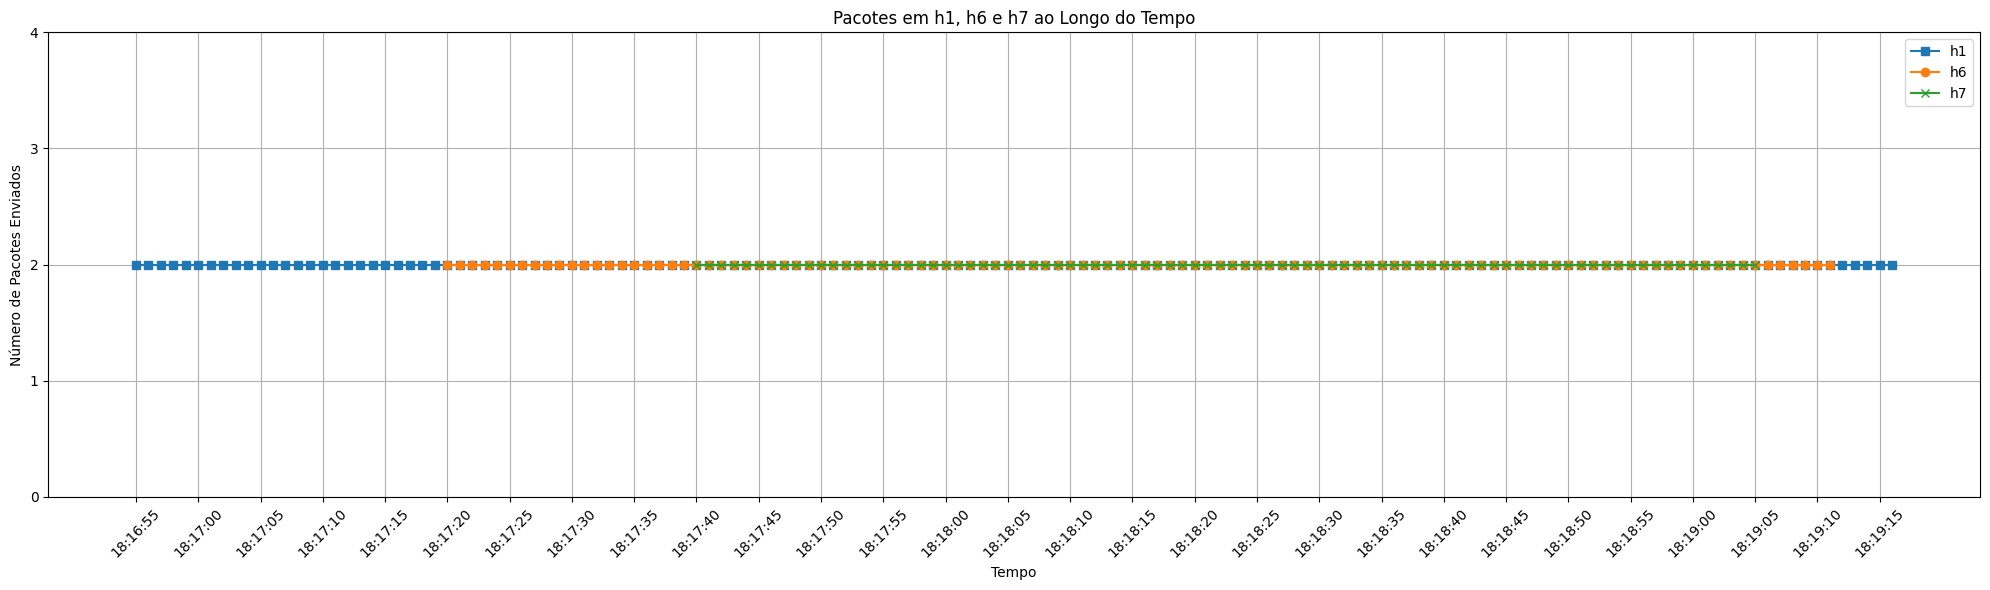

In [143]:
packet_count_h1 = defaultdict(int)
packet_count_h6 = defaultdict(int)
packet_count_h7 = defaultdict(int)

for packet in packets:
    if packet.haslayer("IP"):
        ip_layer = packet["IP"]
        # Se o pacote foi enviado pelo host com IP 10.0.0.1
        if ip_layer.src == '10.0.0.1':
            # Converte o timestamp do pacote para um intervalo de tempo (ex: segundos)
            timestamp = datetime.fromtimestamp(float(packet.time)).strftime("%H:%M:%S")
            packet_count_h1[timestamp] += 1
        elif ip_layer.src == '10.0.0.4':
            # Converte o timestamp do pacote para um intervalo de tempo (ex: segundos)
            timestamp = datetime.fromtimestamp(float(packet.time)).strftime("%H:%M:%S")
            packet_count_h6[timestamp] += 1
        elif ip_layer.src == '10.0.0.5':
            # Converte o timestamp do pacote para um intervalo de tempo (ex: segundos)
            timestamp = datetime.fromtimestamp(float(packet.time)).strftime("%H:%M:%S")
            packet_count_h7[timestamp] += 1
            
times_h1 = sorted(packet_count_h1.keys())
times_h6 = sorted(packet_count_h6.keys())
times_h7 = sorted(packet_count_h7.keys())

packet_counts_h1 = [packet_count_h1[time] for time in times_h1]
packet_counts_h6 = [packet_count_h6[time] for time in times_h6]
packet_counts_h7 = [packet_count_h7[time] for time in times_h7]

plt.figure(figsize=(20, 6))
plt.plot(times_h1, packet_counts_h1, marker='s', label='h1')
plt.plot(times_h6, packet_counts_h6, marker='o', label='h6')
plt.plot(times_h7, packet_counts_h7, marker='x', label='h7')

plt.xlabel('Tempo')
plt.ylabel('Número de Pacotes Enviados')
plt.title(f'Pacotes em h1, h6 e h7 ao Longo do Tempo')
plt.ylim(0, 4)  # Limites do eixo Y entre 0 e 4
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(1))  # Marcas de 2 em 2 no eixo Y
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: int(x)))
plt.xticks(times_h1[::5], rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('pacotes_por_cliente.png')

plt.show()

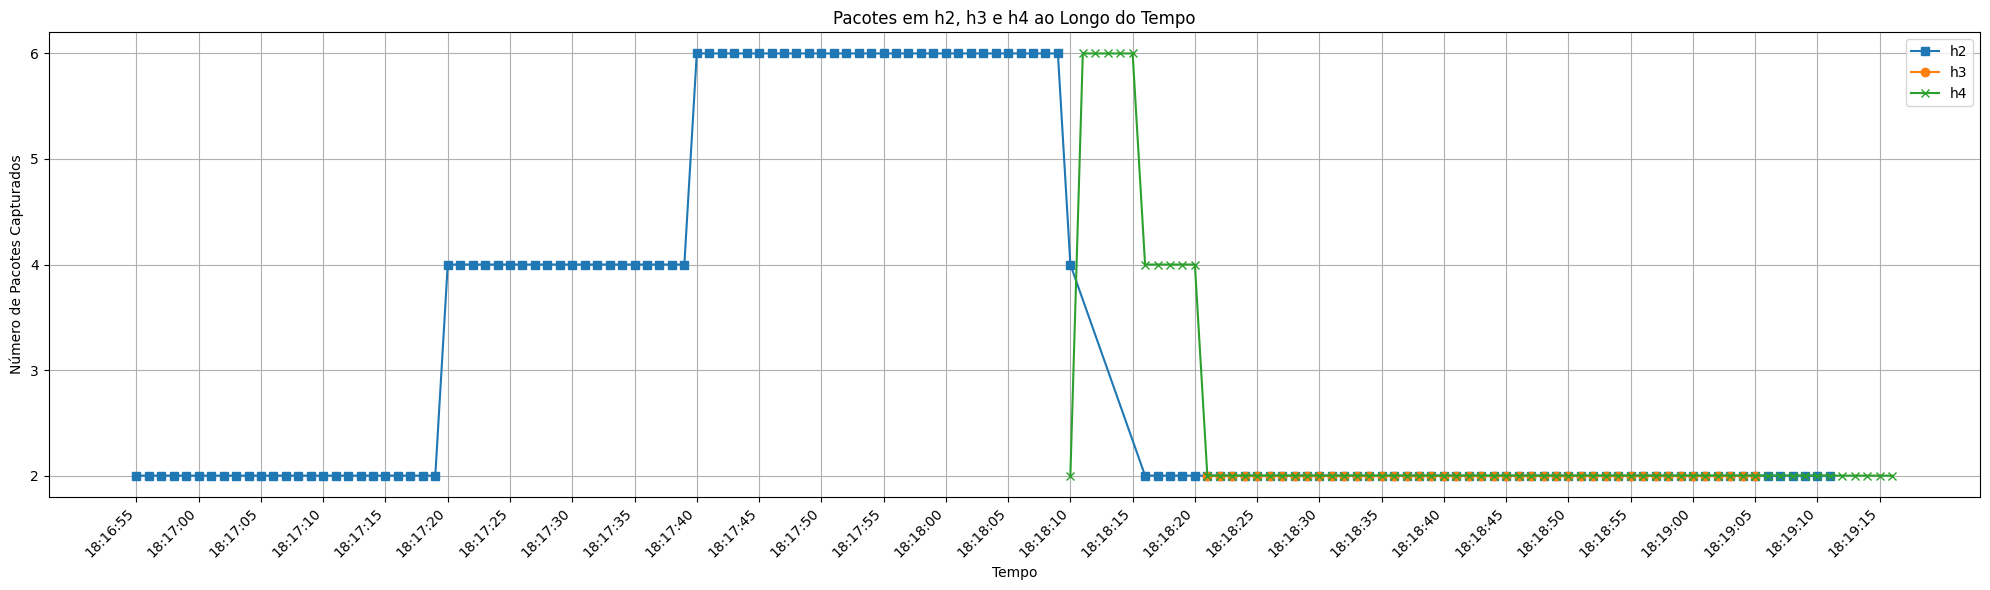

In [125]:
def to_datetime(time_str):
    return datetime.strptime(f"2024-10-09 {time_str}", "%Y-%m-%d %H:%M:%S")

# Dicionários para contar pacotes por tempo para cada interface
packet_count_s1_eth2 = defaultdict(int)
packet_count_s1_eth3 = defaultdict(int)
packet_count_s1_eth4 = defaultdict(int)

excluded_ip = []

# Filtrar pacotes capturados em s1-eth2 e s1-eth4
for packet in packets:
    if packet.haslayer("IP") and packet.haslayer("TCP"):
        ip_layer = packet["IP"]
        # Verifica se o pacote foi capturado em s1-eth2
        if hasattr(packet, "sniffed_on") and packet.sniffed_on == "s1-eth2":
            timestamp = datetime.fromtimestamp(float(packet.time)).strftime("%H:%M:%S")
            packet_count_s1_eth2[timestamp] += 1
        # Verifica se o pacote foi capturado em s1-eth2
        elif hasattr(packet, "sniffed_on") and packet.sniffed_on == "s1-eth3":
            timestamp = datetime.fromtimestamp(float(packet.time)).strftime("%H:%M:%S")
            packet_count_s1_eth3[timestamp] += 1
        # Verifica se o pacote foi capturado em s1-eth4
        elif hasattr(packet, "sniffed_on") and packet.sniffed_on == "s1-eth4" and ip_layer.src not in excluded_ip and ip_layer.dst not in excluded_ip:
            timestamp = datetime.fromtimestamp(float(packet.time)).strftime("%H:%M:%S")
            packet_count_s1_eth4[timestamp] += 1

# Ordenar por tempo
times_eth2 = sorted(packet_count_s1_eth2.keys())
times_eth3 = sorted(packet_count_s1_eth3.keys())
times_eth4 = sorted(packet_count_s1_eth4.keys())

# Contagem de pacotes por tempo para cada interface
packet_counts_eth2 = [packet_count_s1_eth2[time] for time in times_eth2]
packet_counts_eth3 = [packet_count_s1_eth3[time] for time in times_eth3]
packet_counts_eth4 = [packet_count_s1_eth4[time] for time in times_eth4]

# Organizar os dados para tratar as lacunas e acertar o eixo y
times_eth2 = [to_datetime(t) for t in times_eth2]
times_eth3 = [to_datetime(t) for t in times_eth3]
times_eth4 = [to_datetime(t) for t in times_eth4]

df_eth2 = pd.DataFrame({'count': packet_counts_eth2}, index=times_eth2)
df_eth3 = pd.DataFrame({'count': packet_counts_eth3}, index=times_eth3)
df_eth4 = pd.DataFrame({'count': packet_counts_eth4}, index=times_eth4)

start_time = min(df_eth2.index.min(), df_eth4.index.min())
end_time = max(df_eth2.index.max(), df_eth4.index.max())
full_range = pd.date_range(start_time, end_time, freq='1s')

df_eth2 = df_eth2.reindex(full_range)
df_eth3 = df_eth3.reindex(full_range)
df_eth4 = df_eth4.reindex(full_range)

plt.figure(figsize=(20, 6))

# Definir o eixo x com todos os valores de eth2 e eth4
#x_axis_mixed = sorted(set(times_eth2) | set(times_eth4))

# Curva para s1-eth2
#plt.plot(times_eth2, packet_counts_eth2, marker='s', label='h2')
plt.plot(df_eth2.index[df_eth2['count'].notna()], 
         df_eth2['count'].dropna(), 
         marker='s', linestyle='-', label='h2')

# Curva para s1-eth3
#plt.plot(times_eth3, packet_counts_eth3, marker='o', label='h3')
plt.plot(df_eth3.index[df_eth3['count'].notna()], 
         df_eth3['count'].dropna(), 
         marker='o', linestyle='-', label='h3')

# Curva para s1-eth4
#plt.plot(times_eth4, packet_counts_eth4, marker='x', label='h4')
plt.plot(df_eth4.index[df_eth4['count'].notna()], 
         df_eth4['count'].dropna(), 
         marker='x', linestyle='-', label='h4')

# Configurar o gráfico
plt.xlabel('Tempo')
plt.ylabel('Número de Pacotes Capturados')
plt.title('Pacotes em h2, h3 e h4 ao Longo do Tempo')
#plt.xticks(times_eth2[::5], rotation=45)
# Configurar os ticks do eixo x
tick_locations = pd.date_range(start=start_time, end=end_time, freq='5s')
tick_labels = [t.strftime('%H:%M:%S') for t in tick_locations]
plt.xticks(tick_locations, tick_labels, rotation=45, ha='right')

plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M:%S'))
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Números inteiros em y
plt.legend()  # Adiciona legenda para diferenciar as curvas
plt.grid()
plt.tight_layout()
plt.savefig('pacotes_por_interface.png')

# Mostrar o gráfico
plt.show()

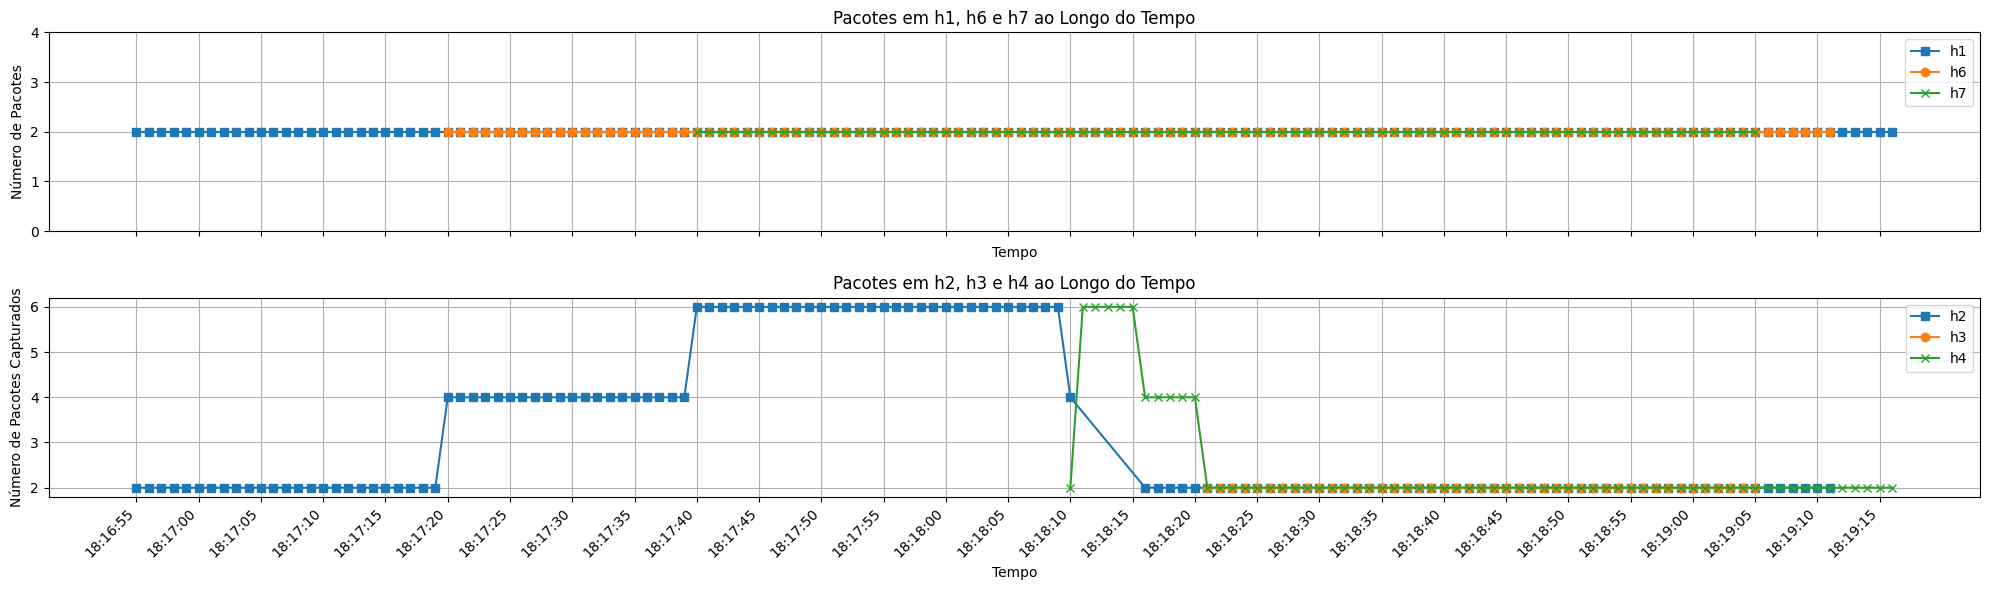

In [141]:
packet_count_h1 = defaultdict(int)
packet_count_h6 = defaultdict(int)
packet_count_h7 = defaultdict(int)

packet_count_s1_eth2 = defaultdict(int)
packet_count_s1_eth3 = defaultdict(int)
packet_count_s1_eth4 = defaultdict(int)

excluded_ip = []

for packet in packets:
    if packet.haslayer("IP"):
        ip_layer = packet["IP"]
        # Se o pacote foi enviado pelo host com IP 10.0.0.1
        if ip_layer.src == '10.0.0.1':
            # Converte o timestamp do pacote para um intervalo de tempo (ex: segundos)
            timestamp = datetime.fromtimestamp(float(packet.time)).strftime("%H:%M:%S")
            packet_count_h1[timestamp] += 1
        elif ip_layer.src == '10.0.0.4':
            # Converte o timestamp do pacote para um intervalo de tempo (ex: segundos)
            timestamp = datetime.fromtimestamp(float(packet.time)).strftime("%H:%M:%S")
            packet_count_h6[timestamp] += 1
        elif ip_layer.src == '10.0.0.5':
            # Converte o timestamp do pacote para um intervalo de tempo (ex: segundos)
            timestamp = datetime.fromtimestamp(float(packet.time)).strftime("%H:%M:%S")
            packet_count_h7[timestamp] += 1
            
for packet in packets:
    if packet.haslayer("IP") and packet.haslayer("TCP"):
        ip_layer = packet["IP"]
        # Verifica se o pacote foi capturado em s1-eth2
        if hasattr(packet, "sniffed_on") and packet.sniffed_on == "s1-eth2":
            timestamp = datetime.fromtimestamp(float(packet.time)).strftime("%H:%M:%S")
            packet_count_s1_eth2[timestamp] += 1
        # Verifica se o pacote foi capturado em s1-eth2
        elif hasattr(packet, "sniffed_on") and packet.sniffed_on == "s1-eth3":
            timestamp = datetime.fromtimestamp(float(packet.time)).strftime("%H:%M:%S")
            packet_count_s1_eth3[timestamp] += 1
        # Verifica se o pacote foi capturado em s1-eth4
        elif hasattr(packet, "sniffed_on") and packet.sniffed_on == "s1-eth4" and ip_layer.src not in excluded_ip and ip_layer.dst not in excluded_ip:
            timestamp = datetime.fromtimestamp(float(packet.time)).strftime("%H:%M:%S")
            packet_count_s1_eth4[timestamp] += 1

times_h1 = sorted(packet_count_h1.keys())
times_h6 = sorted(packet_count_h6.keys())
times_h7 = sorted(packet_count_h7.keys())
times_eth2 = sorted(packet_count_s1_eth2.keys())
times_eth3 = sorted(packet_count_s1_eth3.keys())
times_eth4 = sorted(packet_count_s1_eth4.keys())

packet_counts_h1 = [packet_count_h1[time] for time in times_h1]
packet_counts_h6 = [packet_count_h6[time] for time in times_h6]
packet_counts_h7 = [packet_count_h7[time] for time in times_h7]
packet_counts_eth2 = [packet_count_s1_eth2[time] for time in times_eth2]
packet_counts_eth3 = [packet_count_s1_eth3[time] for time in times_eth3]
packet_counts_eth4 = [packet_count_s1_eth4[time] for time in times_eth4]

# Organizar os dados para tratar as lacunas e acertar o eixo y
times_eth2 = [to_datetime(t) for t in times_eth2]
times_eth3 = [to_datetime(t) for t in times_eth3]
times_eth4 = [to_datetime(t) for t in times_eth4]

df_eth2 = pd.DataFrame({'count': packet_counts_eth2}, index=times_eth2)
df_eth3 = pd.DataFrame({'count': packet_counts_eth3}, index=times_eth3)
df_eth4 = pd.DataFrame({'count': packet_counts_eth4}, index=times_eth4)

start_time = min(df_eth2.index.min(), df_eth4.index.min())
end_time = max(df_eth2.index.max(), df_eth4.index.max())
full_range = pd.date_range(start_time, end_time, freq='1s')

df_eth2 = df_eth2.reindex(full_range)
df_eth3 = df_eth3.reindex(full_range)
df_eth4 = df_eth4.reindex(full_range)

plt.figure(figsize=(20, 6))
plt.subplot(2,1,1)
plt.plot(times_h1, packet_counts_h1, marker='s', label='h1')
plt.plot(times_h6, packet_counts_h6, marker='o', label='h6')
plt.plot(times_h7, packet_counts_h7, marker='x', label='h7')

plt.xlabel('Tempo')
plt.ylabel('Número de Pacotes')
plt.title(f'Pacotes em h1, h6 e h7 ao Longo do Tempo')
plt.xticks(times_h1[::5], rotation=45)
plt.ylim(0, 4)
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(1))  # Valores de 2 em 2 no eixo Y
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: int(x)))
#plt.gca().xaxis.set_visible(False)
plt.gca().set_xticklabels([])
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.subplot(2,1,2)

plt.plot(times_eth2, packet_counts_eth2, marker='s', label='h2')
plt.plot(times_eth3, packet_counts_eth3, marker='o', label='h3')
plt.plot(times_eth4, packet_counts_eth4, marker='x', label='h4')

# Configurar o gráfico
plt.xlabel('Tempo')
plt.ylabel('Número de Pacotes Capturados')
plt.title('Pacotes em h2, h3 e h4 ao Longo do Tempo')
tick_locations = pd.date_range(start=start_time, end=end_time, freq='5s')
tick_labels = [t.strftime('%H:%M:%S') for t in tick_locations]
plt.xticks(tick_locations, tick_labels, rotation=45, ha='right')

plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M:%S'))
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Números inteiros em y
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig('pacotes_clientes_servidores.png')

plt.show()

In [92]:
df = pd.DataFrame({'Time':times_eth4, 'Packet Count':packet_counts_eth4})
df.to_csv('data_eth4.csv', index=False)